In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp/ipykernel_17420/1736925853.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [2]:
cns_dfs = {}
for grouping in ["whole", "arms", "10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	print(f"Loading {grouping}...")
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns.only_aut(cns.add_total_cn(cns_df))
samples_df["type"].value_counts().head()

Loading whole...
Loading arms...
Loading 10MB...
Loading 5MB...
Loading 3MB...
Loading 2MB...
Loading 1MB...
Loading 500KB...
Loading 250KB...


type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [3]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "LUSC"
val_count = 5

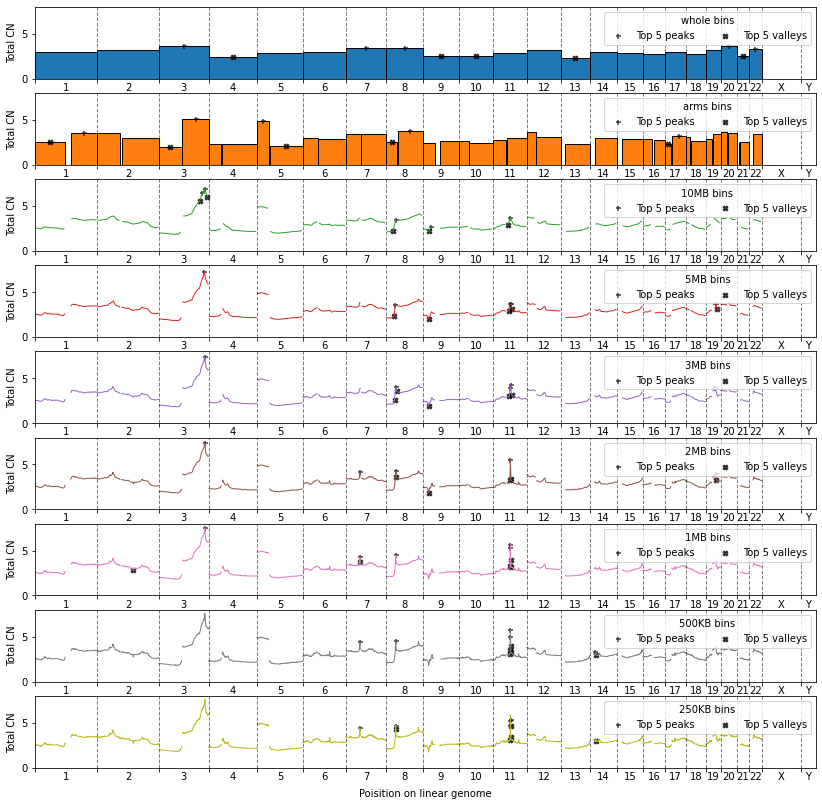

In [4]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	group_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	group_df["sample_id"] = f"mean {cancer_type} CN"
	group_df = cns.add_cum_mid(group_df)
	if grouping == "whole":
		group_by = "sample"
	elif grouping == "arms":
		group_by = "chrom"
	else:
		group_by = "cons"
	group_df["score"] = cns.calc_angles(group_df, "total_cn", group_by=group_by)

	if grouping == "whole" or grouping == "arms":
		cns.plot_bars(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	else:
		cns.plot_lines(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	group_df = group_df.sort_values(by="score")
	axs[i].scatter(group_df["cum_mid"].head(val_count), group_df["total_cn"].head(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(group_df["cum_mid"].tail(val_count), group_df["total_cn"].tail(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig(f"peaks_valleys_{cancer_type}")

In [5]:
cns_dfs.pop("whole", None)
cns_dfs.pop("arms", None)

,sample_id,chrom,start,end,major_cn,minor_cn,name,total_cn
0,SP101724,chr1,0,121485434,2.093344,1.955438,chr1p,4.048782
1,SP101724,chr1,142535434,249250621,2.033594,1.727148,chr1q,3.760742
2,SP101724,chr10,0,39154935,2.160304,1.061700,chr10p,3.222004
3,SP101724,chr10,42354935,135534747,2.028445,1.052366,chr10q,3.080812
4,SP101724,chr11,0,51594205,2.037535,2.000000,chr11p,4.037535
...,...,...,...,...,...,...,...,...
395715,TCGA-ZX-AA5X,chr7,61054331,159138663,2.000000,2.000000,chr7q,4.000000
395716,TCGA-ZX-AA5X,chr8,0,43838887,2.000000,2.000000,chr8p,4.000000
395717,TCGA-ZX-AA5X,chr8,46838887,146364022,2.000000,1.985682,chr8q,3.985682
395718,TCGA-ZX-AA5X,chr9,0,47317679,2.000000,2.000000,chr9p,4.000000


In [6]:
score_means = []

def get_gouping_type(bins):
	if bins == "whole":
		return "sample"
	elif bins == "arms":
		return "chrom"
	else:
		return "cons"

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	# skip if does not start with a number
	if grouping[0].isalpha():
		continue
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn", get_gouping_type(grouping))	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=True).head(10))
cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

       chrom      start        end             name     score  total_cn  \
3698   chr11   70049268   70053496  ENSG00000168040 -1.532864  5.679763   
3691   chr11   69455854   69469242  ENSG00000110092 -1.221489  5.861743   
18149   chr8   38268655   38326352  ENSG00000077782 -0.940400  4.711992   
14166   chr3  181429713  181432221  ENSG00000181449 -0.649780  7.500447   
17294   chr7   55086713   55324313  ENSG00000146648 -0.462318  4.433787   
14152   chr3  178865901  178957881  ENSG00000121879 -0.295182  6.923450   
18498   chr8  128747679  128753674  ENSG00000136997 -0.277115  4.476789   
18781   chr9   35073831   35080013  ENSG00000221829 -0.236994  2.902800   
10988   chr2   61108655   61158745  ENSG00000162924 -0.233901  4.186584   
10986   chr2   60678301   60780702  ENSG00000119866 -0.233549  4.191277   

         gene  
3698     FADD  
3691    CCND1  
18149   FGFR1  
14166    SOX2  
17294    EGFR  
14152  PIK3CA  
18498     MYC  
18781   FANCG  
10988     REL  
10986  BCL11A 

In [23]:
mean_df["abs_score"] = mean_df["score"].abs()
cosmic_sorted = mean_df[~mean_df["gene"].isna()].sort_values(by="abs_score", ascending=False)[["chrom", "score", "gene", "abs_score", "total_cn"]].set_index("gene")
cosmic_sorted.head(10)

,chrom,score,abs_score,total_cn
gene,,,,
FADD,chr11,-1.532864,1.532864,5.679763
CCND1,chr11,-1.221489,1.221489,5.861743
FGFR1,chr8,-0.940400,0.940400,4.711992
SOX2,chr3,-0.649780,0.649780,7.500447
EGFR,chr7,-0.462318,0.462318,4.433787
CDKN2A,chr9,0.433489,0.433489,1.751129
WRN,chr8,0.390897,0.390897,2.266430
NRG1,chr8,0.389553,0.389553,2.387967
LEPROTL1,chr8,0.378527,0.378527,2.248219


In [22]:
print(mean_df.sort_values(by="score", ascending=False).head(10)[["chrom", "start", "end", "score", "gene", "name", "abs_score", "total_cn"]].set_index("name"))

                 chrom     start       end     score    gene  abs_score  \
name                                                                      
ENSG00000147883   chr9  22002901  22009362  0.433489     NaN   0.433489   
ENSG00000224854   chr9  21967136  21967738  0.433489     NaN   0.433489   
ENSG00000147889   chr9  21967750  21995300  0.433489  CDKN2A   0.433489   
ENSG00000176399   chr9  22446839  22455739  0.420338     NaN   0.420338   
ENSG00000264545   chr9  21802634  22032985  0.418780     NaN   0.418780   
ENSG00000099810   chr9  21802541  21931646  0.410839     NaN   0.410839   
ENSG00000110075  chr11  68228185  68382802  0.394055     NaN   0.394055   
ENSG00000165392   chr8  30891316  31031285  0.390897     WRN   0.390897   
ENSG00000162337  chr11  68080076  68216743  0.390573     NaN   0.390573   
ENSG00000157168   chr8  31496901  32622548  0.389553    NRG1   0.389553   

                 total_cn  
name                       
ENSG00000147883  1.751129  
ENSG00000224854

In [13]:
print(mean_df.sort_values(by="abs_score", ascending=False).head(10)[["chrom", "start", "end", "score", "gene", "name", "abs_score", "total_cn"]].set_index("name"))

                 chrom     start       end     score  gene  abs_score  \
name                                                                    
ENSG00000168040  chr11  70049268  70053496 -1.532864  FADD   1.532864   
ENSG00000131626  chr11  70116805  70230509 -1.532864   NaN   1.532864   
ENSG00000085733  chr11  70244509  70282690 -1.524714   NaN   1.524714   
ENSG00000131620  chr11  69924407  70035634 -1.521180   NaN   1.521180   
ENSG00000162341  chr11  68816364  68858072 -1.457377   NaN   1.457377   
ENSG00000172935  chr11  68771862  68780877 -1.447313   NaN   1.447313   
ENSG00000268351  chr11  69587253  69587718 -1.423302   NaN   1.423302   
ENSG00000075388  chr11  69587796  69590171 -1.423302   NaN   1.423302   
ENSG00000186895  chr11  69624991  69633792 -1.423302   NaN   1.423302   
ENSG00000172927  chr11  69061604  69182494 -1.249229   NaN   1.249229   

                 total_cn  
name                       
ENSG00000168040  5.679763  
ENSG00000131626  5.679763  
ENSG0000008

In [34]:
cosmic_sorted.query("chrom == 'chr11'")

,chrom,score,abs_score,total_cn
gene,,,,
FADD,chr11,-1.532864,1.532864,5.679763
CCND1,chr11,-1.221489,1.221489,5.861743
MEN1,chr11,0.333295,0.333295,2.967225
FEN1,chr11,0.234399,0.234399,2.896613
SDHAF2,chr11,0.233537,0.233537,2.896387
BIRC3,chr11,-0.165077,0.165077,3.100260
EXT2,chr11,-0.087024,0.087024,3.038649
LMO1,chr11,0.084960,0.084960,2.456369
CLP1,chr11,0.061459,0.061459,2.999993


We therefore focused on relative effects: when applied to the COSMIC gene set (i.e. where cancer effect is already expected), our method determines the top 5 genes to be FADD (OS=1.53), CCND1 (OS=1.22), FGFR1 (OS=0.94), SOX2 (OS=0.65), and EGFR (OS=0.46). 

In [ ]:
ordered_df = mean_df.sort_values(by=["score"], ascending=False)
ordered_df["score"].sum()
tsgs_df = ordered_df.query("score > 0")[["chrom", "start", "end", "name", "score"]].copy()
print(tsgs_df["score"].describe())
print(tsgs_df["score"].sum())
tsgs_df.to_csv(cdu.pjoin(cdu.out_path, "tsgs_cnsistent_full.tsv"), sep="\t", index=False, header=False)
ogs_df = ordered_df.query("score <= 0")[["chrom", "start", "end", "name", "score"]].copy()
ogs_df["score"] = -ogs_df["score"] 
print(ogs_df["score"].describe())
print(ogs_df["score"].sum())
ogs_df.to_csv(cdu.pjoin(cdu.out_path, "ogs_cnsistent_full.tsv"), sep="\t", index=False, header=False)

count    10779.000000
mean         0.408439
std          0.289654
min          0.000066
25%          0.165220
50%          0.340567
75%          0.618840
max          1.137887
Name: score, dtype: float64
4402.561504648123
count    8651.000000
mean        0.538313
std         0.589229
min         0.000070
25%         0.188290
50%         0.444599
75%         0.664292
max         4.409223
Name: score, dtype: float64
4656.949782649969


In [ ]:

for group in ["all", "LUAD", "LUSC", "KIRC", "PRAD", "BRCA", "OV" ]:
	score_df = pd.read_csv(cdu.pjoin(cdu.out_path, f"gene_scores_{group}.tsv"), sep="\t")
	ordered_df = score_df.sort_values(by=["score"], ascending=False)
	ordered_df["score"].sum()
	tsgs_df = ordered_df.query("score > 0")[["chrom", "start", "end", "name", "score"]].copy()
	print(tsgs_df["score"].describe())
	print(tsgs_df["score"].sum())
	tsgs_df.to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_{group}.tsv"), sep="\t", index=False, header=False)
	ogs_df = ordered_df.query("score <= 0")[["chrom", "start", "end", "name", "score"]].copy()
	ogs_df["score"] = -ogs_df["score"] 
	print(ogs_df["score"].describe())
	print(ogs_df["score"].sum())
	ogs_df.to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_{group}.tsv"), sep="\t", index=False, header=False)

count    1.082300e+04
mean     1.345256e-02
std      1.838550e-02
min      2.243588e-07
25%      2.976725e-03
50%      7.392868e-03
75%      1.561704e-02
max      1.904567e-01
Name: score, dtype: float64
145.5971093880375
count    8607.000000
mean        0.016324
std         0.033292
min        -0.000000
25%         0.002047
50%         0.006316
75%         0.015336
max         0.423611
Name: score, dtype: float64
140.50056772914922
count    10487.000000
mean         0.022010
std          0.026041
min          0.000002
25%          0.005304
50%          0.013316
75%          0.026851
max          0.235467
Name: score, dtype: float64
230.82237135768517
count    8943.000000
mean        0.025417
std         0.050511
min        -0.000000
25%         0.003856
50%         0.010909
75%         0.026793
max         0.667064
Name: score, dtype: float64
227.30834823060053
count    10779.000000
mean         0.408439
std          0.289654
min          0.000066
25%          0.165220
50%          0.